# Test Agent based model simulate VOC transmission inner Chinese cities
## Based on the `Covasim` model

In [2]:
import covasim as cv
import numpy as np
import pandas as pd

Covasim 3.1.2 (2022-01-16) — © 2020-2022 by IDM


In [3]:
def vaccinate_by_age(sim):
    child = cv.true(sim.people.age <= 18) # cv.true() returns indices of people matching this condition, i.e. people under 50
    adult = cv.true((sim.people.age > 18) * (sim.people.age < 65)) # Multiplication means "and" here
    old    = cv.true(sim.people.age >= 65)
    inds = sim.people.uid # Everyone in the population -- equivalent to np.arange(len(sim.people))
    vals = np.ones(len(sim.people)) # Create the array
    vals[child] = 0.15
    vals[adult] = 0.62
    vals[old] = 0.66
    output = dict(inds=inds, vals=vals)
    return output

vaccine = cv.simple_vaccine(days=0, rel_sus=0.65, rel_symp=0.05, subtarget=vaccinate_by_age)

In [20]:

hunan_pop = {
   '0-9':  911,
  '10-19': 1424,
  '20-29': 1957,
  '30-39': 3500,
  '40-49': 2242,
  '50-59': 1982,
  '60-69': 627,
  '70-79': 280,
  '80+':   80,
}

cv.data.country_age_data.data['Hunan'] = hunan_pop

pars = dict(
    pop_size = 50e3,
    pop_infected = 10,
    start_day = '2021-07-22',
    end_day = '2022-01-22',
    location = 'Hunan'
)

sim = cv.Sim(pars = pars)

Initializing sim (resetting people) with 50000 people for 184 days
Loading location-specific data for "Hunan"
  Running 2021-07-22 ( 0/184) (0.00 s)  ———————————————————— 1%
  Running 2021-08-01 (10/184) (0.07 s)  •——————————————————— 6%
  Running 2021-08-11 (20/184) (0.14 s)  ••—————————————————— 11%
  Running 2021-08-21 (30/184) (0.22 s)  •••————————————————— 17%
  Running 2021-08-31 (40/184) (0.30 s)  ••••———————————————— 22%
  Running 2021-09-10 (50/184) (0.38 s)  •••••——————————————— 28%
  Running 2021-09-20 (60/184) (0.50 s)  ••••••—————————————— 33%
  Running 2021-09-30 (70/184) (0.65 s)  •••••••————————————— 38%
  Running 2021-10-10 (80/184) (0.83 s)  ••••••••———————————— 44%
  Running 2021-10-20 (90/184) (1.00 s)  •••••••••——————————— 49%
  Running 2021-10-30 (100/184) (1.15 s)  ••••••••••—————————— 55%
  Running 2021-11-09 (110/184) (1.28 s)  ••••••••••••———————— 60%
  Running 2021-11-19 (120/184) (1.41 s)  •••••••••••••——————— 65%
  Running 2021-11-29 (130/184) (1.52 s)  •••

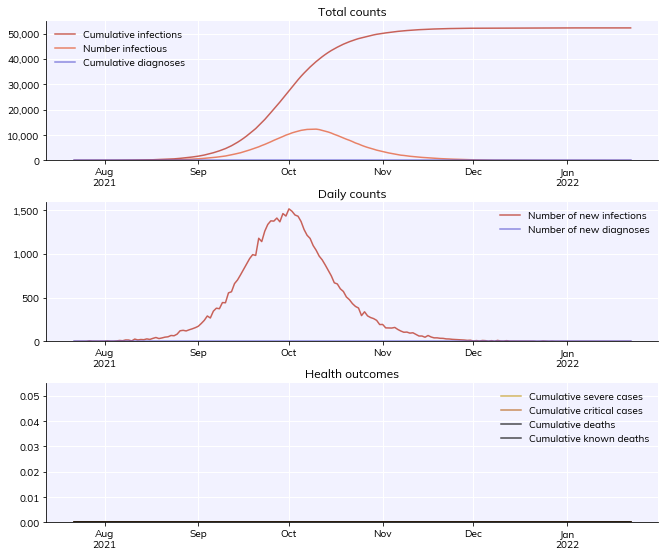

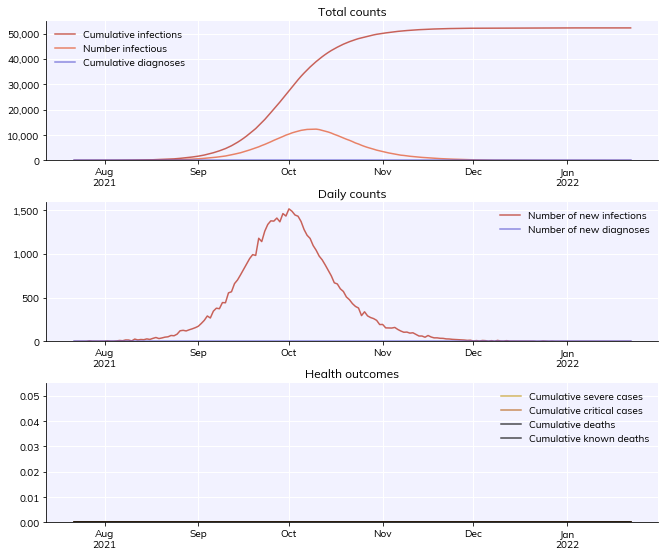

In [26]:
sim.initialize(reset = True)
sim['dur']['exp2inf']  = dict(dist='lognormal_int', par1=4.5, par2=1.5) # Duration from exposed to infectious (presymptomatic and asymptomatic)
sim['dur']['inf2sym'] = dict(dist='lognormal_int', par1=1.1, par2=0.9) # Duration from infectious to mild;
sim['dur']['mild2rec'] = dict(dist='lognormal_int', par1=8.0, par2=2.0) # Duration from mild to recover;
sim['dur']['asym2rec'] = dict(dist='lognormal_int', par1=8.0, par2=2.0) # Duration from asymptomatic to recover;
sim['dur']['rel_symp_prob'] = 0.9 # Proportion of symptomatic case
sim['rel_severe_prob'] = 0 # Proportion of symptomatic case become severe cases

sim.run()
sim.plot()

Initializing sim with 50000 people for 184 days
Loading location-specific data for "Hunan"
Initializing sim with 50000 people for 184 days
Loading location-specific data for "Hunan"
  Running "Baseline": 2021-07-22 ( 0/184) (0.54 s)  ———————————————————— 1%
  Running "With age-targeted vaccine": 2021-07-22 ( 0/184) (0.54 s)  ———————————————————— 1%
  Running "Baseline": 2021-08-01 (10/184) (0.62 s)  •——————————————————— 6%
  Running "With age-targeted vaccine": 2021-08-01 (10/184) (0.63 s)  •——————————————————— 6%
  Running "Baseline": 2021-08-11 (20/184) (0.70 s)  ••—————————————————— 11%
  Running "With age-targeted vaccine": 2021-08-11 (20/184) (0.71 s)  ••—————————————————— 11%
  Running "Baseline": 2021-08-21 (30/184) (0.78 s)  •••————————————————— 17%
  Running "With age-targeted vaccine": 2021-08-21 (30/184) (0.80 s)  •••————————————————— 17%
  Running "Baseline": 2021-08-31 (40/184) (0.86 s)  ••••———————————————— 22%
  Running "With age-targeted vaccine": 2021-08-31 (40/184) (0

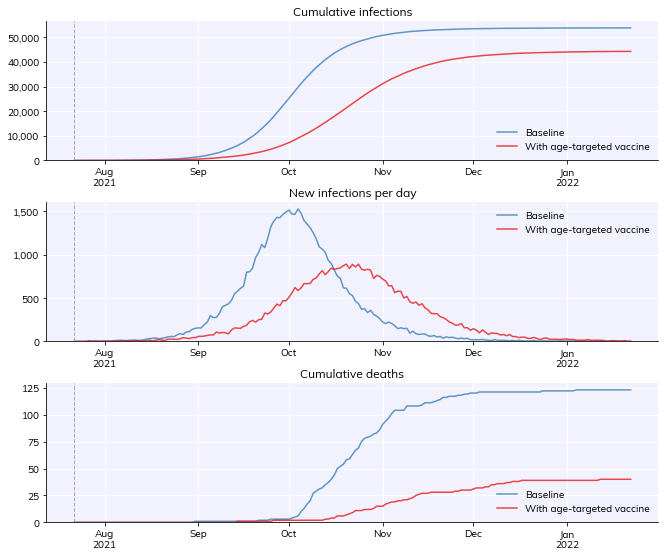

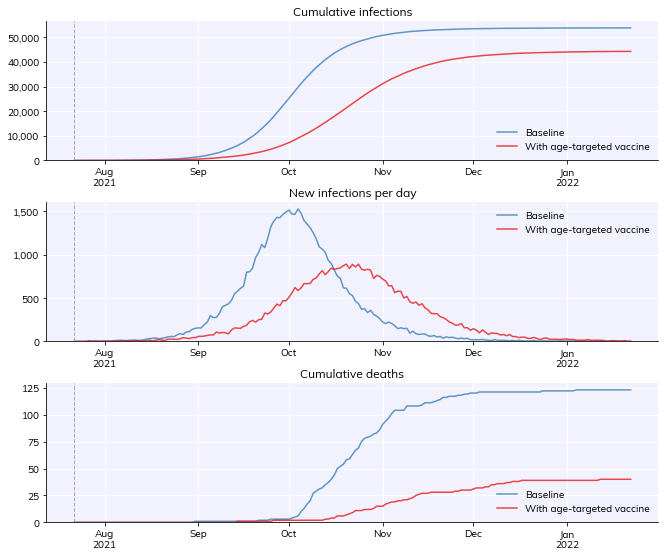

In [24]:
sim1 = cv.Sim(pars = pars, label='Baseline')
sim2 = cv.Sim(pars = pars, interventions=vaccine, label='With age-targeted vaccine')
msim = cv.parallel(sim1, sim2)
msim.plot()